# Minimal test: task-routed **comms on vs off** × **task similarity** (same / near / far)

For **each** similarity: one participant (`study1_{same|near|far}_sub1` by default), **two** runs differing only in **sparsity** (`1` vs `0`). Outputs:

`data/simulations/{RUN_TAG}_seed{SEED}/{same|near|far}/comms_on/` and `.../comms_off/`

with post-phase **`core_per_module`** / **`comms_per_module`** on the ordered sweep.

**Note:** “Comms” = **comms RNN branch** (`community.py`); `sparsity=0` masks inter-module **recurrent** weights but the branch can stay non-zero from inputs.

**Edit** `SIMILARITY_RUNS`, `N_EPOCHS`, `SEED` below, then run all cells.

Later sections add **during-training** plots (loss / hidden norms from `npz`) and **`training_proxy_summary_by_similarity.csv`** — still no core/comms *during* batches unless you extend `train_participant_schedule`.

In [7]:
import sys
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

project_root = Path(os.getcwd()).resolve()
while not (project_root / "a1b2").exists():
    if project_root == project_root.parent:
        raise RuntimeError("Project root (containing a1b2) not found.")
    project_root = project_root.parent
sys.path.insert(0, str(project_root))
os.chdir(project_root)

from a1b2.training.simulation import run_simulation
from a1b2.analysis import transfer_interference as ann

try:
    from IPython.display import display
except ImportError:
    display = print

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except ImportError:
    sns = None

data_folder = project_root / "data"
config_path = project_root / "a1b2" / "models" / "experiments.json"
with open(config_path, "r") as f:
    settings = json.load(f)

print("Project root:", project_root)

Project root: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular


## Configuration

- **`SIMILARITY_RUNS`**: list of `(task_similarity, participant_id)` — default `study1_*_sub1` for same / near / far.
- **`CONDITION_FULL` / `CONDITION_NONE`**: names in `experiments.json`.
- **`N_TRIALS_MULTIPLIER`**: 5 = fast; 10 = closer to main sims.

In [8]:
# --- edit ---
SIMILARITY_RUNS = [
    ("same", "study1_same_sub1"),
    ("near", "study1_near_sub1"),
    ("far", "study1_far_sub1"),
]
N_EPOCHS = 8
N_TRIALS_MULTIPLIER = 5
SEED = 42
CONDITION_FULL = "two_module_rnn_25_task_routed_nb2"
CONDITION_NONE = "two_module_rnn_25_task_routed_no_comms_nb2"
RUN_TAG = "task_routed_comms_minimal"
# ------------

SIM_ORDER = ["same", "near", "far"]


def condition_by_name(settings, name: str) -> dict:
    for c in settings["conditions"]:
        if c.get("name") == name:
            return dict(c)
    raise KeyError(f"Condition not found: {name}")


cond_full = condition_by_name(settings, CONDITION_FULL)
cond_none = condition_by_name(settings, CONDITION_NONE)
for lbl, c in [("full", cond_full), ("no_comms", cond_none)]:
    print(lbl, "→ sparsity", c.get("sparsity"), "input_routing", c.get("input_routing", "shared"), "nb_steps", c.get("nb_steps", 1))

base_out = data_folder / "simulations" / f"{RUN_TAG}_seed{SEED}"
base_out.mkdir(parents=True, exist_ok=True)

task_parameters = ann.setup_task_parameters()
dim_input = task_parameters["nStim_perTask"] * 2
dim_output = 4
lr = settings.get("learning_rate", 1e-2)

df_all = ann.load_participant_data(str(data_folder))
all_p = set(df_all["participant"].unique())
for sim, pid in SIMILARITY_RUNS:
    if pid not in all_p:
        raise ValueError(f"Participant {pid} not in trial_df — fix SIMILARITY_RUNS for similarity={sim}")
    n = len(df_all[df_all["participant"] == pid])
    print(f"{sim:4s} → {pid} ({n} rows)")

SIMILARITY_FOLDERS = {}
for sim, pid in SIMILARITY_RUNS:
    root = base_out / sim
    (root / "comms_on").mkdir(parents=True, exist_ok=True)
    (root / "comms_off").mkdir(parents=True, exist_ok=True)
    SIMILARITY_FOLDERS[sim] = {"participant": pid, "on": root / "comms_on", "off": root / "comms_off"}

print("Output root:", base_out)

full → sparsity 1 input_routing task_routed nb_steps 2
no_comms → sparsity 0 input_routing task_routed nb_steps 2
same → study1_same_sub1 (360 rows)
near → study1_near_sub1 (360 rows)
far  → study1_far_sub1 (360 rows)
Output root: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations/task_routed_comms_minimal_seed42


## Run paired simulations (per similarity)

Same `SEED` before each `run_simulation`. Saves under `.../{same|near|far}/comms_on|off/`.

In [9]:
def run_one(condition: dict, sim_folder: Path, participants: list, df_participant: pd.DataFrame):
    hidden_size = condition.get("dim_hidden", 25)
    n_modules = condition.get("n_modules", 2)
    dim_hidden = n_modules * hidden_size
    gamma = condition.get("gamma", 0.0) or 0.0
    shuffle = True
    batch_size = 16
    n_phase = 3
    n_train_trials = N_EPOCHS * dim_input * N_TRIALS_MULTIPLIER
    training_params = [participants, n_phase, N_EPOCHS, n_train_trials, shuffle, batch_size, gamma, lr]
    network_params = [dim_input, dim_hidden, dim_output]
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    results = run_simulation(
        training_params=training_params,
        network_params=network_params,
        task_parameters=task_parameters,
        df=df_participant,
        do_test=0,
        dosave=1,
        sim_folder=str(sim_folder),
        arch="two_module_rnn",
        condition=condition,
    )
    meta = {
        "condition_name": condition.get("name"),
        "sparsity": condition.get("sparsity"),
        "participant": participants[0],
        "n_epochs": N_EPOCHS,
        "seed": SEED,
    }
    with open(sim_folder / "minimal_run_meta.json", "w") as f:
        json.dump(meta, f, indent=2)
    return results


for sim, pid in SIMILARITY_RUNS:
    paths = SIMILARITY_FOLDERS[sim]
    df_p = df_all[df_all["participant"] == pid].copy()
    print(f"=== {sim} ({pid}) comms on ===")
    run_one(cond_full, paths["on"], [pid], df_p)
    print(f"=== {sim} ({pid}) comms off ===")
    run_one(cond_none, paths["off"], [pid], df_p)

print("Done. Saved under:", base_out)

=== same (study1_same_sub1) comms on ===


Participants: 100%|██████████| 1/1 [00:00<00:00,  1.05it/s]


=== same (study1_same_sub1) comms off ===


Participants: 100%|██████████| 1/1 [00:00<00:00,  1.12it/s]


=== near (study1_near_sub1) comms on ===


...

=== far (study1_far_sub1) comms on ===


Participants: 100%|██████████| 1/1 [00:00<00:00,  1.19it/s]


=== far (study1_far_sub1) comms off ===


Participants: 100%|██████████| 1/1 [00:00<00:00,  1.13it/s]

Done. Saved under: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations/task_routed_comms_minimal_seed42


## Load npz — verify core/comms keys (first similarity)

In [10]:
def load_npz(folder: Path, participant: str):
    path = folder / f"sim_{participant}.npz"
    with np.load(path, allow_pickle=True) as z:
        return {k: z[k] for k in z.files}


first_sim, first_pid = SIMILARITY_RUNS[0]
d0 = load_npz(SIMILARITY_FOLDERS[first_sim]["on"], first_pid)
core_keys = [k for k in d0 if "core_per_module" in k]
comms_keys = [k for k in d0 if "comms_per_module" in k]
print("core keys:", core_keys)
print("comms keys:", comms_keys)
if not core_keys:
    print("WARN: no core/comms in npz.")

core keys: ['hiddens_post_phase_0_core_per_module', 'hiddens_post_phase_1_core_per_module', 'hiddens_post_phase_2_core_per_module']
comms keys: ['hiddens_post_phase_0_comms_per_module', 'hiddens_post_phase_1_comms_per_module', 'hiddens_post_phase_2_comms_per_module']


## Summarize core vs comms + phase losses (all similarities)

In [11]:
def core_comms_table(d: dict, run_label: str, task_similarity: str) -> pd.DataFrame:
    rows = []
    for ph in (0, 1, 2):
        ck = f"hiddens_post_phase_{ph}_core_per_module"
        vk = f"hiddens_post_phase_{ph}_comms_per_module"
        if ck not in d or vk not in d:
            continue
        core = np.asarray(d[ck], dtype=float)
        comms = np.asarray(d[vk], dtype=float)
        if core.ndim != 3:
            continue
        _, n_mod, _ = core.shape
        for m in range(n_mod):
            nc = np.linalg.norm(core[:, m, :], axis=1)
            nv = np.linalg.norm(comms[:, m, :], axis=1)
            rows.append(
                {
                    "task_similarity": task_similarity,
                    "run": run_label,
                    "phase": ph,
                    "phase_name": ["A1", "B", "A2"][ph],
                    "module": m,
                    "mean_L2_core": float(np.nanmean(nc)),
                    "mean_L2_comms": float(np.nanmean(nv)),
                    "comms_over_core": float(np.nanmean(nv) / (np.nanmean(nc) + 1e-12)),
                }
            )
    return pd.DataFrame(rows)


def phase_mean_loss(d, ph):
    x = d["losses"][ph]
    m = np.isfinite(x)
    return float(np.mean(x[m])) if m.any() else np.nan


tab_parts = []
beh_parts = []
for sim, pid in SIMILARITY_RUNS:
    paths = SIMILARITY_FOLDERS[sim]
    for label, key in [("comms_on", "on"), ("comms_off", "off")]:
        d = load_npz(paths[key], pid)
        t = core_comms_table(d, label, sim)
        tab_parts.append(t)
        beh_parts.append(
            {
                "task_similarity": sim,
                "run": label,
                "participant": pid,
                **{f"loss_ph{ph}": phase_mean_loss(d, ph) for ph in range(3)},
            }
        )

tab = pd.concat(tab_parts, ignore_index=True)
tab["task_similarity"] = pd.Categorical(tab["task_similarity"], categories=SIM_ORDER, ordered=True)
beh = pd.DataFrame(beh_parts)
beh["task_similarity"] = pd.Categorical(beh["task_similarity"], categories=SIM_ORDER, ordered=True)

display(tab)
out_csv = base_out / "core_comms_minimal_summary_by_similarity.csv"
tab.to_csv(out_csv, index=False)
beh.to_csv(base_out / "phase_loss_minimal_by_similarity.csv", index=False)
print("Wrote:", out_csv)

print("Mean training loss per phase:")
display(beh.sort_values(["task_similarity", "run"]))

piv = tab.pivot_table(
    index=["task_similarity", "phase", "phase_name"],
    columns="run",
    values="mean_L2_comms",
    aggfunc="mean",
)
if "comms_on" in piv.columns and "comms_off" in piv.columns:
    piv["delta_comms_on_minus_off"] = piv["comms_on"] - piv["comms_off"]
    print("Δ mean ‖comms‖ (comms_on − comms_off), averaged over modules:")
    display(piv[["comms_on", "comms_off", "delta_comms_on_minus_off"]].reset_index())

,task_similarity,run,phase,phase_name,module,mean_L2_core,mean_L2_comms,comms_over_core
0,same,comms_on,0,A1,0,0.436301,0.456557,1.046427
1,same,comms_on,0,A1,1,0.445066,0.444752,0.999293
2,same,comms_on,1,B,0,0.435746,0.455336,1.044959
3,same,comms_on,1,B,1,0.443368,0.443885,1.001166
4,same,comms_on,2,A2,0,0.436979,0.455904,1.043309
5,same,comms_on,2,A2,1,0.444507,0.444394,0.999746
6,same,comms_off,0,A1,0,0.436280,0.405104,0.928540
7,same,comms_off,0,A1,1,0.445091,0.416495,0.935752
8,same,comms_off,1,B,0,0.435720,0.404381,0.928074
9,same,comms_off,1,B,1,0.443401,0.415709,0.937545


Wrote: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations/task_routed_comms_minimal_seed42/core_comms_minimal_summary_by_similarity.csv
Mean training loss per phase:


,task_similarity,run,participant,loss_ph0,loss_ph1,loss_ph2
1,same,comms_off,study1_same_sub1,0.505074,0.527097,0.485585
0,same,comms_on,study1_same_sub1,0.507971,0.528718,0.487901
3,near,comms_off,study1_near_sub1,0.510853,0.473386,0.491592
2,near,comms_on,study1_near_sub1,0.517587,0.475107,0.496716
5,far,comms_off,study1_far_sub1,0.515600,0.482472,0.485589
4,far,comms_on,study1_far_sub1,0.519853,0.479652,0.488732


Δ mean ‖comms‖ (comms_on − comms_off), averaged over modules:


/tmp/ipykernel_2685096/61463339.py:68: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  piv = tab.pivot_table(


run,task_similarity,phase,phase_name,comms_on,comms_off,delta_comms_on_minus_off
0,same,0,A1,0.450655,0.410799,0.039855
1,same,1,B,0.449611,0.410045,0.039566
2,same,2,A2,0.450149,0.410575,0.039574
3,near,0,A1,0.450609,0.410911,0.039699
4,near,1,B,0.451429,0.411704,0.039726
5,near,2,A2,0.451784,0.412220,0.039564
6,far,0,A1,0.450633,0.410832,0.039801
7,far,1,B,0.452137,0.411348,0.040788
8,far,2,A2,0.452430,0.411711,0.040719


## Plots: ‖comms‖ by phase, faceted by task similarity

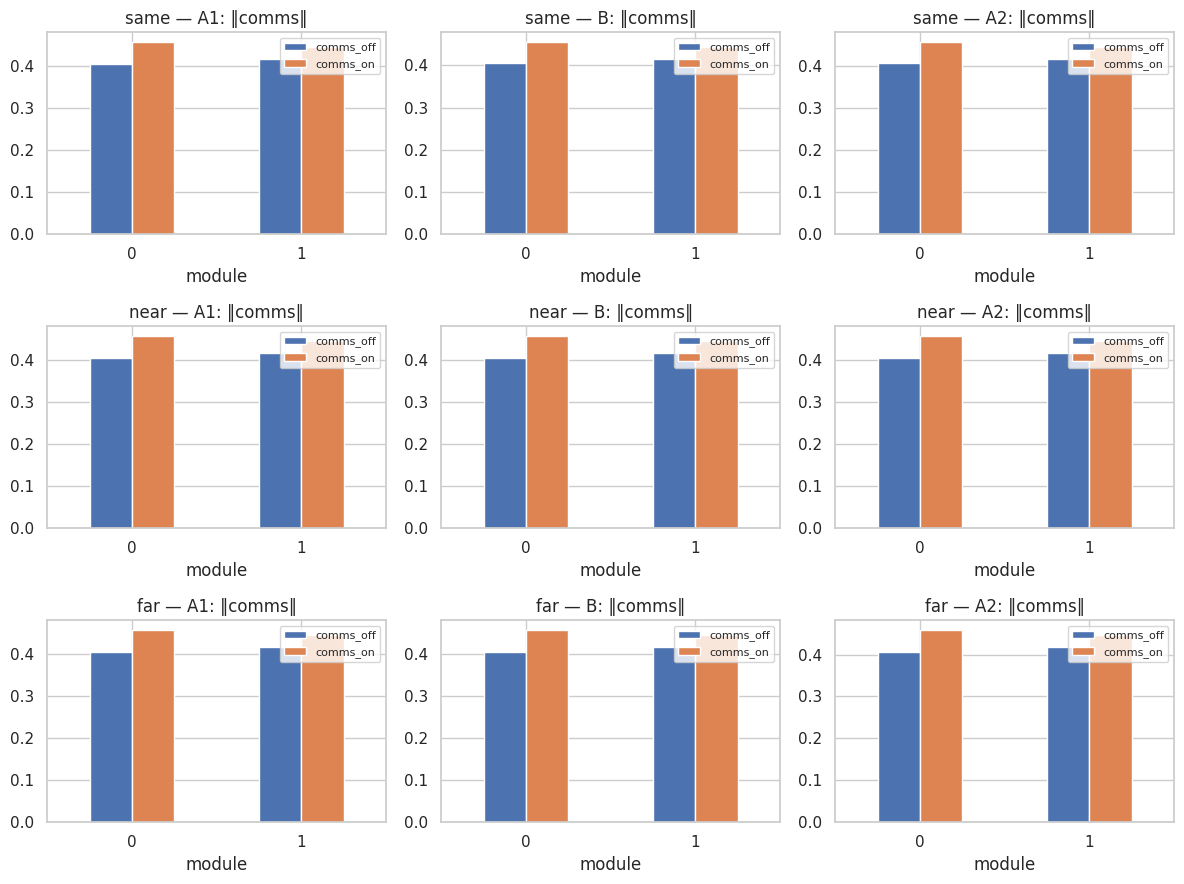

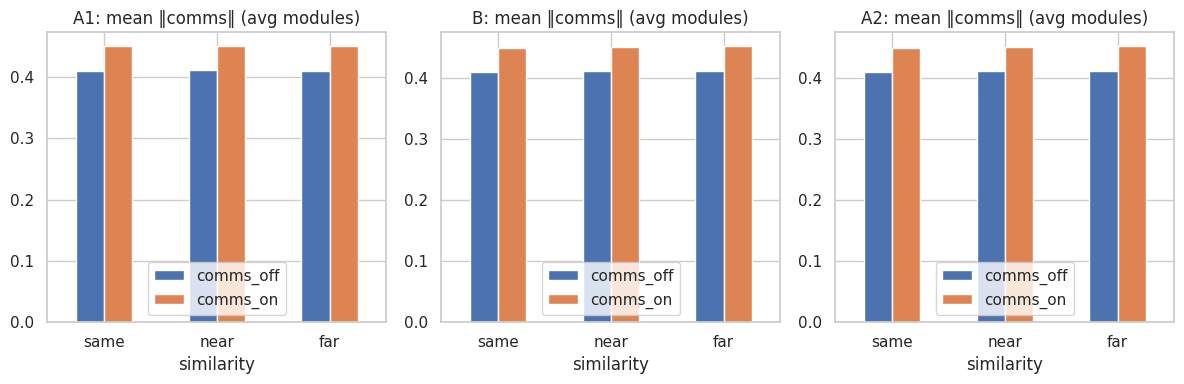

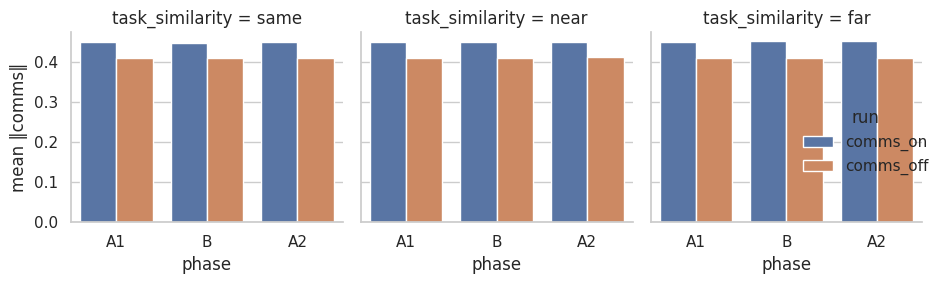

In [12]:
if len(tab) == 0:
    print("No rows to plot.")
else:
    phase_names = ["A1", "B", "A2"]
    fig, axes = plt.subplots(len(SIMILARITY_RUNS), 3, figsize=(12, 3 * len(SIMILARITY_RUNS)), squeeze=False)
    for ri, (sim, _) in enumerate(SIMILARITY_RUNS):
        for ci, ph in enumerate([0, 1, 2]):
            ax = axes[ri][ci]
            sub = tab[(tab["task_similarity"] == sim) & (tab["phase"] == ph)]
            if sub.empty:
                ax.set_title(f"{sim} {phase_names[ph]} (no data)")
                continue
            piv = sub.pivot_table(index="module", columns="run", values="mean_L2_comms", aggfunc="first")
            piv.plot(kind="bar", ax=ax, rot=0)
            ax.set_title(f"{sim} — {phase_names[ph]}: ‖comms‖")
            ax.set_xlabel("module")
            ax.legend(title="", fontsize=8)
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ci, ph in enumerate([0, 1, 2]):
        ax = axes[ci]
        sub = tab[tab["phase"] == ph]
        agg = sub.groupby(["task_similarity", "run"], observed=True)["mean_L2_comms"].mean().unstack("run")
        if not agg.empty:
            agg.plot(kind="bar", ax=ax, rot=0)
        ax.set_title(f"{phase_names[ph]}: mean ‖comms‖ (avg modules)")
        ax.set_xlabel("similarity")
        ax.legend(title="")
    plt.tight_layout()
    plt.show()

    if sns is not None:
        sub = tab.copy()
        g = sns.catplot(
            data=sub,
            x="phase_name",
            y="mean_L2_comms",
            hue="run",
            col="task_similarity",
            col_order=SIM_ORDER,
            kind="bar",
            errorbar=None,
            height=3,
            aspect=0.9,
        )
        g.set_axis_labels("phase", "mean ‖comms‖")
        plt.tight_layout()
        plt.show()

## During-training proxies (from `npz` — no extra simulator runs)

Uses **`losses`**, **`probes`**, **`accuracy`**, and **`hiddens_per_module`** logged on every training step.

- **B phase, `probe == 1`:** B-routed trials — smoothed **loss** and **‖h_A‖ / ‖h_B‖**; overlay **comms_on vs comms_off** per similarity.
- **A2:** smoothed **loss** for **probe 0** vs **probe 1** separately.
- **Table:** `b_final10pct_loss_probe1`, **`a2_loss_gap_p1_minus_p0`**, etc., exported to CSV.

This is **not** core/comms decomposition during training (that would require a training-loop change).

,task_similarity,run,participant,b_mean_loss_probe1,b_final10pct_loss_probe1,b_min_loss_probe1,a2_mean_loss_probe0,a2_mean_loss_probe1,a2_loss_gap_p1_minus_p0
1,same,comms_off,study1_same_sub1,0.526677,0.515069,0.470856,0.482789,0.488382,0.005593
0,same,comms_on,study1_same_sub1,0.528427,0.515574,0.467332,0.485212,0.490591,0.005379
3,near,comms_off,study1_near_sub1,0.470284,0.455814,0.418120,0.489345,0.493839,0.004494
2,near,comms_on,study1_near_sub1,0.471734,0.456350,0.414071,0.494438,0.498994,0.004557
5,far,comms_off,study1_far_sub1,0.482359,0.472136,0.435007,0.483543,0.487634,0.004091
4,far,comms_on,study1_far_sub1,0.479421,0.468122,0.429292,0.486525,0.490940,0.004415


Wrote: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations/task_routed_comms_minimal_seed42/training_proxy_summary_by_similarity.csv


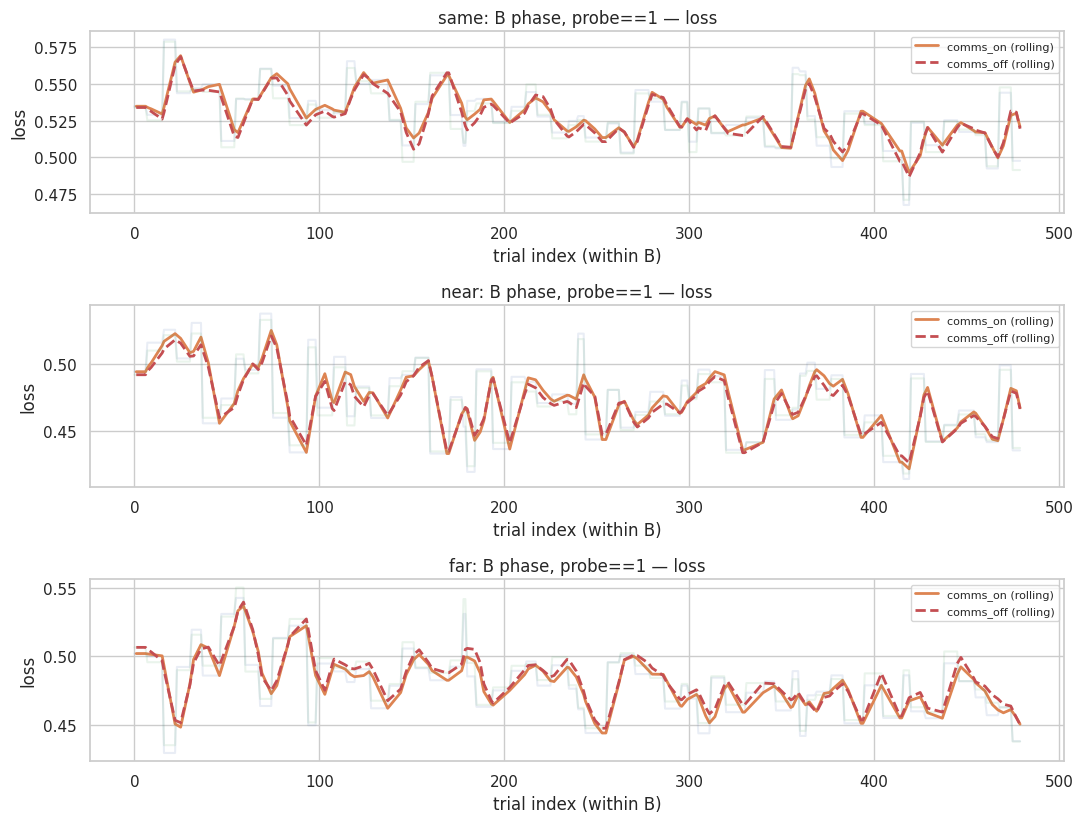

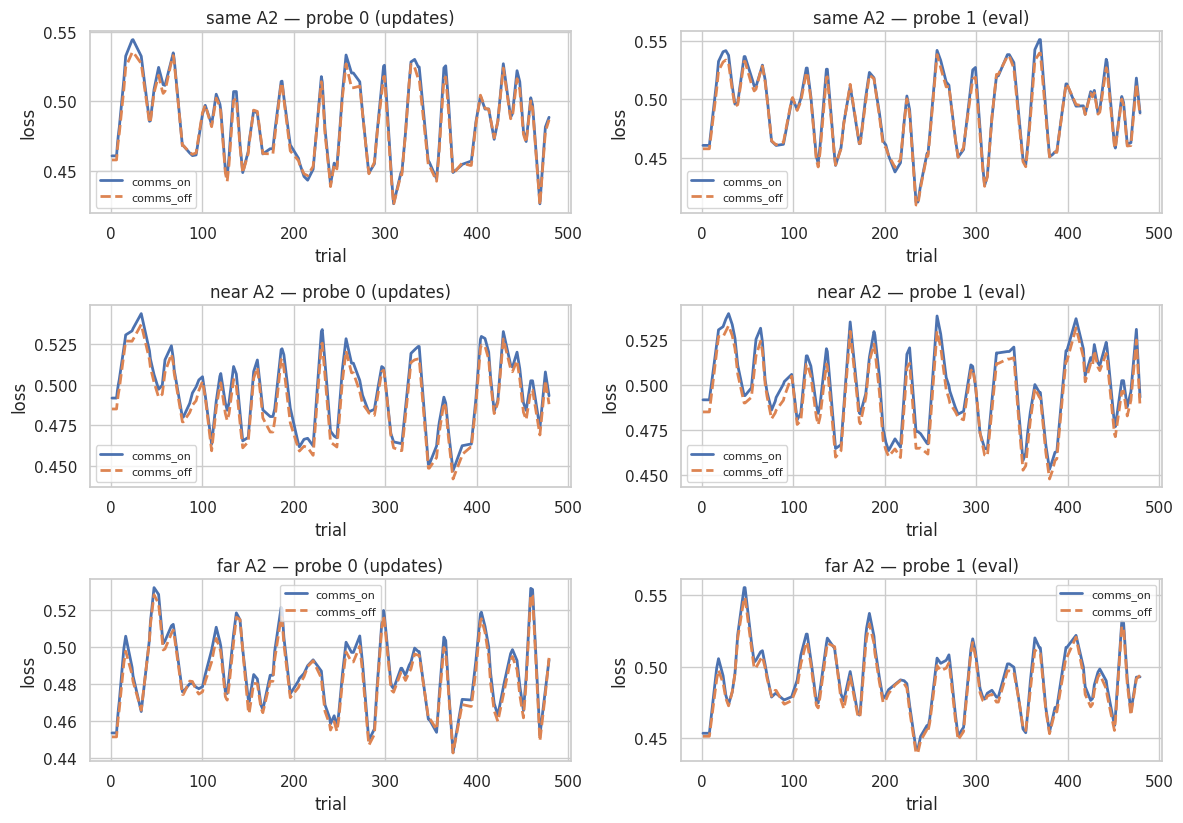

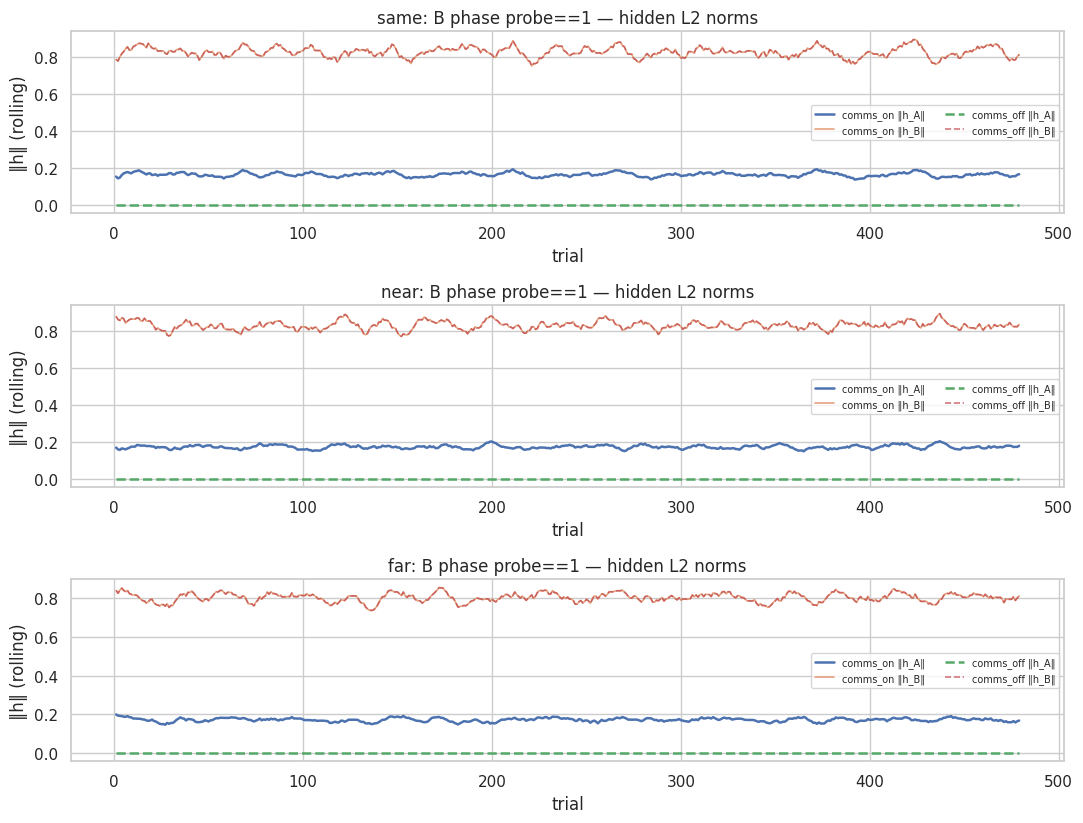

In [13]:
# --- during-training analysis (requires `tab` / `base_out` / `SIMILARITY_*` from above) ---
PHASE_B, PHASE_A2 = 1, 2
MOD_A, MOD_B = 0, 1


def trial_mask_1d(a):
    return np.isfinite(np.asarray(a, dtype=float))


def rolling_mean(x, win):
    x = np.asarray(x, dtype=float)
    return pd.Series(x).rolling(window=win, min_periods=max(1, win // 4)).mean().to_numpy()


def collect_training_metrics():
    rows = []
    for sim, pid in SIMILARITY_RUNS:
        for run_tag, k in [("comms_on", "on"), ("comms_off", "off")]:
            d = load_npz(SIMILARITY_FOLDERS[sim][k], pid)
            losses, probes = d["losses"], d["probes"]

            ph = PHASE_B
            m = trial_mask_1d(losses[ph])
            m1 = m & (probes[ph] == 1)
            if m1.sum() > 0:
                bl = losses[ph, m1]
                last_k = max(1, len(bl) // 10)
                b_final10 = float(np.mean(bl[-last_k:]))
                b_min = float(np.min(bl))
                b_mean = float(np.mean(bl))
            else:
                b_final10 = b_min = b_mean = np.nan

            ph = PHASE_A2
            m = trial_mask_1d(losses[ph])
            m0 = m & (probes[ph] == 0)
            m1p = m & (probes[ph] == 1)
            l0 = float(np.mean(losses[ph, m0])) if m0.sum() else np.nan
            l1 = float(np.mean(losses[ph, m1p])) if m1p.sum() else np.nan
            gap = (l1 - l0) if np.isfinite(l0) and np.isfinite(l1) else np.nan

            rows.append(
                {
                    "task_similarity": sim,
                    "run": run_tag,
                    "participant": pid,
                    "b_mean_loss_probe1": b_mean,
                    "b_final10pct_loss_probe1": b_final10,
                    "b_min_loss_probe1": b_min,
                    "a2_mean_loss_probe0": l0,
                    "a2_mean_loss_probe1": l1,
                    "a2_loss_gap_p1_minus_p0": gap,
                }
            )
    return pd.DataFrame(rows)


training_fx = collect_training_metrics()
training_fx["task_similarity"] = pd.Categorical(
    training_fx["task_similarity"], categories=SIM_ORDER, ordered=True
)
display(training_fx.sort_values(["task_similarity", "run"]))
training_fx.to_csv(base_out / "training_proxy_summary_by_similarity.csv", index=False)
print("Wrote:", base_out / "training_proxy_summary_by_similarity.csv")

win = max(5, min(80, max(N_EPOCHS * dim_input * N_TRIALS_MULTIPLIER // 50, 10)))

# B phase, probe 1: loss trajectories
fig, axes = plt.subplots(len(SIMILARITY_RUNS), 1, figsize=(11, 2.8 * len(SIMILARITY_RUNS)), squeeze=False)
for ri, (sim, pid) in enumerate(SIMILARITY_RUNS):
    ax = axes[ri, 0]
    for run_tag, k, sty in [("comms_on", "on", "-"), ("comms_off", "off", "--")]:
        d = load_npz(SIMILARITY_FOLDERS[sim][k], pid)
        ph = PHASE_B
        m = trial_mask_1d(d["losses"][ph]) & (d["probes"][ph] == 1)
        y = d["losses"][ph, m]
        if len(y) == 0:
            continue
        idx = np.arange(len(y))
        ax.plot(idx, y, alpha=0.12)
        ax.plot(idx, rolling_mean(y, win), linestyle=sty, lw=2, label=f"{run_tag} (rolling)")
    ax.set_title(f"{sim}: B phase, probe==1 — loss")
    ax.set_xlabel("trial index (within B)"); ax.set_ylabel("loss")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# A2: probe 0 vs 1
fig, axes = plt.subplots(len(SIMILARITY_RUNS), 2, figsize=(12, 2.8 * len(SIMILARITY_RUNS)), squeeze=False)
for ri, (sim, pid) in enumerate(SIMILARITY_RUNS):
    for col, (pval, tlab) in enumerate([(0, "probe 0 (updates)"), (1, "probe 1 (eval)")]):
        ax = axes[ri, col]
        for run_tag, k, sty in [("comms_on", "on", "-"), ("comms_off", "off", "--")]:
            d = load_npz(SIMILARITY_FOLDERS[sim][k], pid)
            ph = PHASE_A2
            m = trial_mask_1d(d["losses"][ph]) & (d["probes"][ph] == pval)
            y = d["losses"][ph, m]
            if len(y) == 0:
                continue
            idx = np.arange(len(y))
            ax.plot(idx, rolling_mean(y, win), linestyle=sty, lw=2, label=run_tag)
        ax.set_title(f"{sim} A2 — {tlab}")
        ax.set_xlabel("trial"); ax.set_ylabel("loss")
        ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# B phase probe 1: ‖h‖ per module (if available)
sample_d = load_npz(SIMILARITY_FOLDERS[SIMILARITY_RUNS[0][0]]["on"], SIMILARITY_RUNS[0][1])
if "hiddens_per_module" in sample_d:
    fig, axes = plt.subplots(len(SIMILARITY_RUNS), 1, figsize=(11, 2.8 * len(SIMILARITY_RUNS)), squeeze=False)
    for ri, (sim, pid) in enumerate(SIMILARITY_RUNS):
        ax = axes[ri, 0]
        for run_tag, k, sty in [("comms_on", "on", "-"), ("comms_off", "off", "--")]:
            d = load_npz(SIMILARITY_FOLDERS[sim][k], pid)
            hpm = d["hiddens_per_module"]
            ph = PHASE_B
            m = trial_mask_1d(d["losses"][ph]) & (d["probes"][ph] == 1)
            h = hpm[ph, m]
            if h.shape[0] == 0:
                continue
            n0 = np.linalg.norm(h[:, MOD_A, :], axis=1)
            n1 = np.linalg.norm(h[:, MOD_B, :], axis=1)
            idx = np.arange(len(n0))
            ax.plot(idx, rolling_mean(n0, win), linestyle=sty, lw=1.8, label=f"{run_tag} ‖h_A‖")
            ax.plot(idx, rolling_mean(n1, win), linestyle=sty, lw=1.2, alpha=0.75, label=f"{run_tag} ‖h_B‖")
        ax.set_title(f"{sim}: B phase probe==1 — hidden L2 norms")
        ax.set_xlabel("trial"); ax.set_ylabel("‖h‖ (rolling)")
        ax.legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()
else:
    print("No hiddens_per_module in npz; skip hidden-norm trajectories.")

## What to look for

- **Δ ‖comms‖** (on − off) across **same / near / far** (pilot; N=1 subject per band).
- **Phase losses**: comms_on vs off **within** each similarity.
- Extend **`SIMILARITY_RUNS`** for more participants.
- **During-training section:** compare **comms_on vs off** on **B (probe 1)** and **A2 (probes 0/1)** trajectories; read **`training_proxy_summary_by_similarity.csv`** for scalar gaps.

**Note:** Older runs may live in `..._seed{N}/comms_on` without a `same|near|far` subfolder; this notebook uses **`..._seed{N}/{same,near,far}/comms_on`** only.